<a href="https://colab.research.google.com/github/yoolmalaak/concrete-crack-and-fracture-analysis/blob/main/notebooks/05_cnn_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Evaluation

This notebook evaluates the trained convolutional neural network (CNN) developed for binary classification of cracked and uncracked concrete images from the SDNET2018 dataset. Model performance is assessed using classification metrics, a confusion matrix, threshold analysis, ROC-AUC, and precision–recall analysis. The finalized CNN is subsequently applied to the 6,000-image sample used for crack morphology analysis to obtain image-level crack probabilities and predictions for comparative analysis.

## 1. Environment Setup

This section defines the project paths, imports the required libraries, and identifies the available computational device for CNN evaluation.

In [3]:
!git clone https://github.com/yoolmalaak/concrete-crack-and-fracture-analysis.git

Cloning into 'concrete-crack-and-fracture-analysis'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 116 (delta 36), reused 80 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 38.20 MiB | 20.87 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [4]:
%cd /content/concrete-crack-and-fracture-analysis
!git status

/content/concrete-crack-and-fracture-analysis
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [28]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

PROJECT_ROOT = Path("/content/concrete-crack-and-fracture-analysis")
SDNET_ROOT = Path("/content/sdnet2018/sdnet2018")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Project root:", PROJECT_ROOT)
print("SDNET2018 root:", SDNET_ROOT)
print("Device:", DEVICE)

Project root: /content/concrete-crack-and-fracture-analysis
SDNET2018 root: /content/sdnet2018/sdnet2018
Device: cuda


## 2. Load the Trained CNN Checkpoint

This section loads the best-performing CNN checkpoint selected during training based on validation performance. The checkpoint from epoch 17 is used for subsequent evaluation and inference.

### 2.1 Define the CNN Architecture

The CNN architecture used during training is recreated so that the saved epoch-17 checkpoint can be loaded for evaluation.

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn_model = BaselineCNN().to(DEVICE)

print(cnn_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)


### 2.2 Load the Trained CNN Checkpoint

The trained CNN checkpoint from the selected epoch is loaded and set to evaluation mode for subsequent testing and inference.

In [7]:
from pathlib import Path
import torch

checkpoint_path = PROJECT_ROOT / "trained_models" / "best_cnn.pt"

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

cnn_model.load_state_dict(checkpoint["model_state_dict"])
cnn_model.to(DEVICE)
cnn_model.eval()

print("Checkpoint:", checkpoint_path)
print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])
print("Device:", DEVICE)

Checkpoint: /content/concrete-crack-and-fracture-analysis/trained_models/best_cnn.pt
Epoch: 17
Validation loss: 0.7728277717714557
Validation accuracy: 0.8406227715711909
Device: cuda


## 3. Prepare the SDNET2018 Test Dataset

This section prepares the SDNET2018 test set for evaluating the trained CNN. The dataset structure and image counts are first verified before the test dataset and DataLoader are created.

### 3.1 Extract the SDNET2018 Dataset

The uploaded SDNET2018 ZIP archive is extracted into the Colab working directory. The extracted dataset will be used to reconstruct the test set for CNN evaluation.

In [15]:
from pathlib import Path
import zipfile

zip_path = Path("/content/sdnet2018.zip")
extract_path = Path("/content/sdnet2018")

print("ZIP exists:", zip_path.exists())
print("ZIP size (MB):", round(zip_path.stat().st_size / (1024**2), 2))

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

ZIP exists: True
ZIP size (MB): 508.67
Extraction complete.


In [18]:
from pathlib import Path

PROJECT_ROOT = Path("/content/concrete-crack-and-fracture-analysis")
SDNET_ROOT = Path("/content/sdnet2018/sdnet2018")

print("Project exists:", PROJECT_ROOT.exists())
print("Dataset exists:", SDNET_ROOT.exists())
print("Dataset path:", SDNET_ROOT)

Project exists: True
Dataset exists: True
Dataset path: /content/sdnet2018/sdnet2018


### 3.2 Verify Image Counts

The number of cracked and uncracked images in each SDNET2018 category is verified to ensure that the complete dataset has been extracted correctly before constructing the test set.

In [20]:
surfaces = ["deck", "pavement", "wall"]
classes = ["crack_dataset", "uncrack_dataset"]

for surface in surfaces:
    for class_name in classes:
        folder = SDNET_ROOT / surface / class_name
        images = list(folder.glob("*.jpg"))

        print(
            f"{surface}/{class_name}: "
            f"{len(images)} images"
        )

total_images = len(list(SDNET_ROOT.rglob("*.jpg")))

print("\nTotal images:", total_images)

deck/crack_dataset: 2025 images
deck/uncrack_dataset: 11595 images
pavement/crack_dataset: 2608 images
pavement/uncrack_dataset: 21726 images
wall/crack_dataset: 3851 images
wall/uncrack_dataset: 14287 images

Total images: 56092


### 3.3 Recover the Original Test-Split Logic

The test-set construction used during CNN training is recovered from the training notebook to ensure that evaluation is performed on the same test images and with the same split procedure.

In [22]:
import json

training_notebook = PROJECT_ROOT / "notebooks" / "04_cnn_training.ipynb"

with open(training_notebook, "r", encoding="utf-8") as f:
    training_nb = json.load(f)

for i, cell in enumerate(training_nb["cells"]):
    if cell["cell_type"] == "code":
        source = "".join(cell["source"])

        if any(keyword in source.lower() for keyword in [
            "train_test_split",
            "random_state",
            "test_size",
            "train_indices",
            "test_indices",
            "val_indices",
            "split"
        ]):
            print(f"\n--- Cell {i} ---")
            print(source)


--- Cell 18 ---
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    metadata_df,
    train_size=39264,
    stratify=metadata_df["class_id"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    train_size=8414,
    stratify=temp_df["class_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

--- Cell 116 ---
import pandas as pd

# select candidate crack images by surface type

# Add 'image_name' column to metadata_df if not present
if 'image_name' not in metadata_df.columns:
    metadata_df['image_name'] = metadata_df['image_path'].apply(lambda x: Path(x).name)

crack_df = metadata_df[metadata_df["class_id"] == 1].copy()

candidates_list = []
for surf

## 3.4 Build Dataset Metadata

In [23]:
records = []

for surface in surfaces:
    for class_name in classes:
        folder = SDNET_ROOT / surface / class_name

        class_id = 1 if class_name == "crack_dataset" else 0
        label = "cracked" if class_id == 1 else "uncracked"

        for image_path in folder.glob("*.jpg"):
            records.append({
                "image_path": str(image_path),
                "surface": surface,
                "label": label,
                "class_id": class_id
            })

metadata_df = pd.DataFrame(records)

print("Total images:", len(metadata_df))

print("\nClass distribution:")
print(metadata_df["label"].value_counts())

print("\nSurface distribution:")
print(metadata_df["surface"].value_counts())

Total images: 56092

Class distribution:
label
uncracked    47608
cracked       8484
Name: count, dtype: int64

Surface distribution:
surface
pavement    24334
wall        18138
deck        13620
Name: count, dtype: int64


## 3.5 Verify Dataset Splits

In [29]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    metadata_df,
    train_size=39264,
    stratify=metadata_df["class_id"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    train_size=8414,
    stratify=temp_df["class_id"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training set: 39264
Validation set: 8414
Test set: 8414
Total: 56092


In [31]:
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


### 3.5 Define Evaluation Transformations

The evaluation transformation is applied to the SDNET2018 test images using the same preprocessing defined during CNN development. Unlike the training transformation, no random augmentation is applied during evaluation.

In [32]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Evaluation transform:")
print(eval_transform)

Evaluation transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


### 3.6 Create the Test Dataset and DataLoader

The SDNET2018 test dataset is constructed from the previously generated test split. The dataset applies the evaluation transformation to each image, and a DataLoader is created for batch-based CNN evaluation.

In [33]:
from PIL import Image
from torch.utils.data import Dataset, DataLoader


class SDNETDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = Image.open(row["image_path"]).convert("RGB")
        label = float(row["class_id"])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


test_dataset = SDNETDataset(
    test_df,
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))

Test samples: 8414
Test batches: 132


## 4. Evaluate CNN on the Test Set

The trained CNN is evaluated on the complete SDNET2018 test set. The model outputs are converted to probabilities using the sigmoid function, and predictions are generated using a classification threshold of 0.50.

### 4.1 Generate Predictions

The CNN is applied to all test images in batches. The predicted probabilities and corresponding true labels are stored for subsequent performance evaluation.

In [34]:
all_probabilities = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)

        logits = cnn_model(images)
        probabilities = torch.sigmoid(logits).squeeze(1)

        all_probabilities.extend(probabilities.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probabilities = np.array(all_probabilities)
all_labels = np.array(all_labels)

all_predictions = (all_probabilities >= 0.50).astype(int)

print("Predictions generated:", len(all_predictions))
print("Labels:", len(all_labels))
print("Probabilities:", len(all_probabilities))

Predictions generated: 8414
Labels: 8414
Probabilities: 8414


### 4.2 Calculate Classification Metrics

The CNN predictions are evaluated using accuracy, precision, recall, and F1-score at the primary classification threshold of 0.50.

In [35]:
accuracy = accuracy_score(all_labels, all_predictions)
precision = precision_score(all_labels, all_predictions)
recall = recall_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.8367
Precision: 0.4722
Recall:    0.6800
F1-score:  0.5573


### 4.3 Save Test Performance

The CNN classification metrics obtained on the SDNET2018 test set are saved for later reporting and discussion.

In [36]:
test_performance = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1_score"],
    "value": [accuracy, precision, recall, f1]
})

metrics_path = PROJECT_ROOT / "results" / "metrics" / "cnn_test_performance.csv"
metrics_path.parent.mkdir(parents=True, exist_ok=True)

test_performance.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)
print(test_performance)

Saved: /content/concrete-crack-and-fracture-analysis/results/metrics/cnn_test_performance.csv
      metric     value
0   accuracy  0.836701
1  precision  0.472162
2     recall  0.680031
3   f1_score  0.557345


## 5. Classification Report

The classification report provides class-specific precision, recall, and F1-score for cracked and uncracked concrete images. This provides a more detailed assessment of CNN performance than overall accuracy alone.

In [37]:
report = classification_report(
    all_labels,
    all_predictions,
    target_names=["Uncracked", "Cracked"],
    output_dict=True
)

classification_report_df = pd.DataFrame(report).transpose()

print(classification_report_df.round(4))

              precision  recall  f1-score    support
Uncracked        0.9382  0.8646    0.8999  7142.0000
Cracked          0.4722  0.6800    0.5573  1272.0000
accuracy         0.8367  0.8367    0.8367     0.8367
macro avg        0.7052  0.7723    0.7286  8414.0000
weighted avg     0.8677  0.8367    0.8481  8414.0000


### 5.2 Save the Classification Report

The class-specific CNN performance metrics are saved for inclusion in the results and subsequent discussion.

In [38]:
report_path = PROJECT_ROOT / "results" / "metrics" / "cnn_classification_report.csv"

classification_report_df.to_csv(report_path)

print("Saved:", report_path)

Saved: /content/concrete-crack-and-fracture-analysis/results/metrics/cnn_classification_report.csv


## 6. Confusion Matrix

The confusion matrix is used to examine the distribution of correct and incorrect CNN classifications for cracked and uncracked concrete images.

In [39]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6175  967]
 [ 407  865]]


### 6.2 Plot and Save the Confusion Matrix

The confusion matrix is visualised to provide a clear representation of the CNN classification results for cracked and uncracked concrete images.

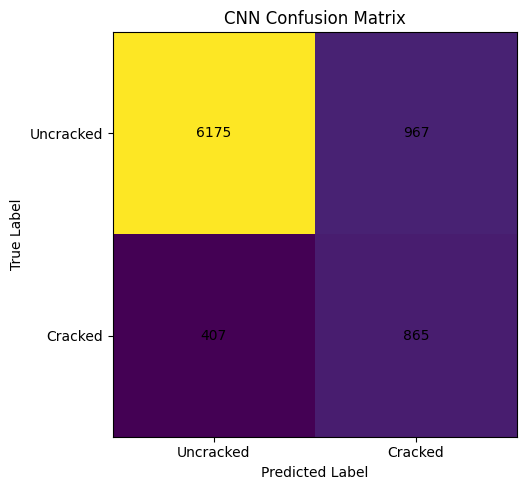

Saved: /content/concrete-crack-and-fracture-analysis/results/figures/cnn_confusion_matrix.png


In [40]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Uncracked", "Cracked"])
ax.set_yticklabels(["Uncracked", "Cracked"])

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("CNN Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

figure_path = PROJECT_ROOT / "results" / "figures" / "cnn_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

### 7.1 Generate the ROC Curve

The receiver operating characteristic (ROC) curve is generated using the CNN-predicted probabilities across a range of classification thresholds. The area under the ROC curve (ROC-AUC) is used to summarize the model's ability to distinguish between cracked and uncracked concrete images.

In [41]:
fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.8553


### 7.2 Plot and Save the ROC Curve

The ROC curve is visualised and saved for reporting the CNN classification performance.

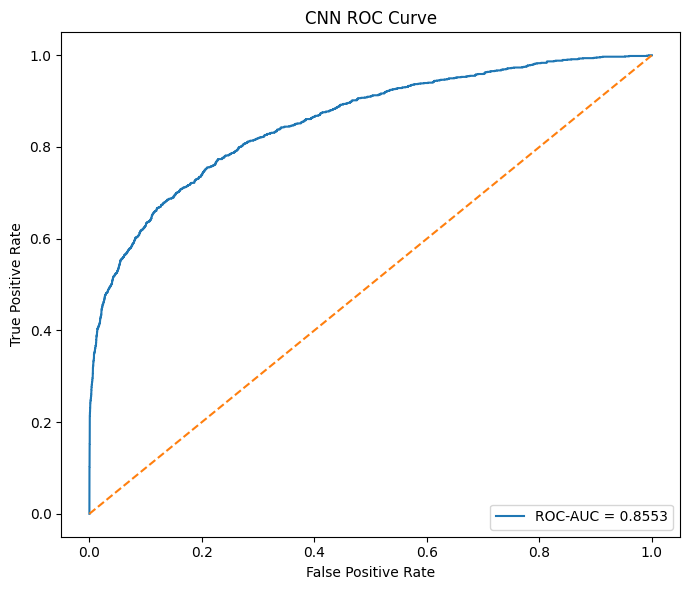

Saved: /content/concrete-crack-and-fracture-analysis/results/figures/cnn_roc_curve.png


In [42]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CNN ROC Curve")
ax.legend(loc="lower right")

plt.tight_layout()

roc_figure_path = PROJECT_ROOT / "results" / "figures" / "cnn_roc_curve.png"
roc_figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", roc_figure_path)

### 7.3 Save ROC Data

The ROC coordinates and ROC-AUC value are saved for reproducibility and later reporting.

In [43]:
roc_data = pd.DataFrame({
    "false_positive_rate": fpr,
    "true_positive_rate": tpr,
    "threshold": thresholds
})

roc_data_path = PROJECT_ROOT / "results" / "metrics" / "cnn_roc_data.csv"
roc_auc_path = PROJECT_ROOT / "results" / "metrics" / "cnn_roc_auc.csv"

roc_data.to_csv(roc_data_path, index=False)

pd.DataFrame({
    "metric": ["roc_auc"],
    "value": [roc_auc]
}).to_csv(roc_auc_path, index=False)

print("Saved:", roc_data_path)
print("Saved:", roc_auc_path)

Saved: /content/concrete-crack-and-fracture-analysis/results/metrics/cnn_roc_data.csv
Saved: /content/concrete-crack-and-fracture-analysis/results/metrics/cnn_roc_auc.csv


## 8. Precision–Recall Analysis

The precision–recall curve is generated using the CNN-predicted probabilities across different classification thresholds. Average precision is used to summarize the precision–recall performance of the CNN for detecting cracked concrete images.

In [44]:
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    all_labels,
    all_probabilities
)

average_precision = average_precision_score(
    all_labels,
    all_probabilities
)

print(f"Average Precision: {average_precision:.4f}")

Average Precision: 0.6610


### 8.2 Plot and Save the Precision–Recall Curve

The precision–recall relationship is visualised to assess the trade-off between correctly identifying cracked images and avoiding false positive classifications.

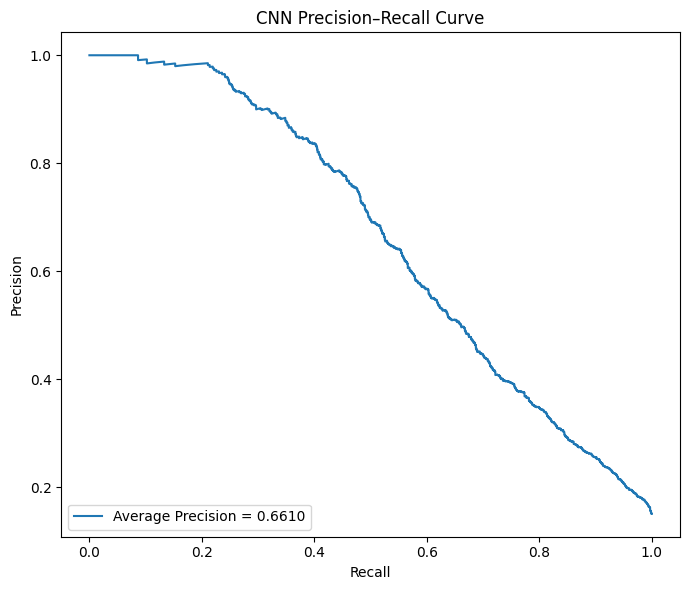

Saved: /content/concrete-crack-and-fracture-analysis/results/figures/cnn_precision_recall_curve.png


In [45]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    recall_values,
    precision_values,
    label=f"Average Precision = {average_precision:.4f}"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("CNN Precision–Recall Curve")
ax.legend(loc="lower left")

plt.tight_layout()

pr_figure_path = PROJECT_ROOT / "results" / "figures" / "cnn_precision_recall_curve.png"
pr_figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    pr_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", pr_figure_path)

### 8.3 Save Precision–Recall Data

The precision–recall coordinates and average precision value are saved for reproducibility and later reporting.

In [46]:
pr_data = pd.DataFrame({
    "recall": recall_values,
    "precision": precision_values
})

pr_data_path = PROJECT_ROOT / "results" / "metrics" / "cnn_precision_recall_data.csv"
ap_path = PROJECT_ROOT / "results" / "metrics" / "cnn_average_precision.csv"

pr_data.to_csv(pr_data_path, index=False)

pd.DataFrame({
    "metric": ["average_precision"],
    "value": [average_precision]
}).to_csv(ap_path, index=False)

print("Saved:", pr_data_path)
print("Saved:", ap_path)

Saved: /content/concrete-crack-and-fracture-analysis/results/metrics/cnn_precision_recall_data.csv
Saved: /content/concrete-crack-and-fracture-analysis/results/metrics/cnn_average_precision.csv


## 9. Apply the CNN to the 6,000-Image Morphology Sample

The trained CNN is applied to the same 6,000 SDNET2018 images selected for crack morphology analysis. This provides image-level CNN predictions that can be compared with the crack morphology features obtained from U-Net segmentation.

### 9.1 Load the Morphology Sample

The previously selected balanced sample of 6,000 SDNET2018 images is loaded for CNN inference. The sample contains equal numbers of cracked and uncracked images across the deck, pavement, and wall surface categories.

In [50]:
morphology_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "sdnet2018_morphology_6000.csv"
)

morphology_df = pd.read_csv(morphology_path)

# Construct the full image_path
morphology_df["image_path"] = morphology_df.apply(
    lambda row: SDNET_ROOT
    / row["category"]
    / ( "crack_dataset" if row["label"] == "cracked" else "uncrack_dataset" )
    / row["image_name"],
    axis=1
)

# Add the class_id column
morphology_df["class_id"] = morphology_df["label"].apply(
    lambda x: 1 if x == "cracked" else 0
)

print("Morphology sample shape:", morphology_df.shape)
print()
print(morphology_df["category"].value_counts())
print()
print(morphology_df["label"].value_counts())
print()
print(morphology_df.head())

Morphology sample shape: (6000, 13)

category
deck        2000
pavement    2000
wall        2000
Name: count, dtype: int64

label
cracked      3000
uncracked    3000
Name: count, dtype: int64

  category    image_name    label  predicted_crack_present  crack_area_ratio  \
0     deck  7036-110.jpg  cracked                        0          0.000000   
1     deck   7017-40.jpg  cracked                        0          0.000000   
2     deck   7017-33.jpg  cracked                        1          0.020325   
3     deck   7028-54.jpg  cracked                        0          0.000000   
4     deck  7057-215.jpg  cracked                        1          0.003906   

   crack_area_percentage  crack_length_pixels  mean_width_pixels  \
0               0.000000             0.000000           0.000000   
1               0.000000             0.000000           0.000000   
2               2.032471           147.953319           6.296442   
3               0.000000             0.000000         

### 9.2 Create the CNN Inference Dataset

A dataset is created from the 6,000-image morphology sample using the same evaluation transformation applied to the CNN test set. The images are processed without random augmentation to ensure consistent inference.

In [54]:
morphology_dataset = SDNETDataset(
    morphology_df,
    transform=eval_transform
)

morphology_loader = DataLoader(
    morphology_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Morphology samples:", len(morphology_dataset))
print("Morphology batches:", len(morphology_loader))

Morphology samples: 6000
Morphology batches: 94


### 9.3 Generate CNN Predictions

The trained CNN is applied to the 6,000-image morphology sample. For each image, the model probability of belonging to the cracked class is recorded together with the corresponding binary prediction using a threshold of 0.50.

In [55]:
morphology_probabilities = []
morphology_predictions = []

with torch.no_grad():
    for images, _ in morphology_loader:
        images = images.to(DEVICE)

        logits = cnn_model(images)
        probabilities = torch.sigmoid(logits).squeeze(1)

        morphology_probabilities.extend(
            probabilities.cpu().numpy()
        )

        morphology_predictions.extend(
            (probabilities >= 0.50).cpu().numpy().astype(int)
        )

morphology_probabilities = np.array(morphology_probabilities)
morphology_predictions = np.array(morphology_predictions)

print("Predictions generated:", len(morphology_predictions))
print("Probabilities generated:", len(morphology_probabilities))
print()
print("CNN predicted classes:")
print(
    pd.Series(morphology_predictions)
    .map({0: "Uncracked", 1: "Cracked"})
    .value_counts()
)

Predictions generated: 6000
Probabilities generated: 6000

CNN predicted classes:
Uncracked    3562
Cracked      2438
Name: count, dtype: int64


### 9.3 Add CNN Results to the Morphology Dataset

The CNN-predicted crack probabilities and classifications are added to the morphology dataset. This creates a combined image-level dataset containing both CNN classification results and U-Net-derived crack morphology features for the same 6,000 images.

In [56]:
morphology_df["cnn_crack_probability"] = morphology_probabilities
morphology_df["cnn_prediction"] = morphology_predictions

print("Updated shape:", morphology_df.shape)

print("\nNew columns:")
print(
    morphology_df[
        ["image_name", "label", "cnn_crack_probability", "cnn_prediction"]
    ].head()
)

Updated shape: (6000, 15)

New columns:
     image_name    label  cnn_crack_probability  cnn_prediction
0  7036-110.jpg  cracked               0.374156               0
1   7017-40.jpg  cracked               0.361578               0
2   7017-33.jpg  cracked               0.990710               1
3   7028-54.jpg  cracked               0.288769               0
4  7057-215.jpg  cracked               0.470610               0


### 9.5 Sanity Check CNN Predictions

The CNN predictions on the 6,000-image morphology sample are compared with the known image labels to verify that the predictions are correctly aligned with the morphology records.

In [57]:
sample_accuracy = accuracy_score(
    morphology_df["class_id"],
    morphology_df["cnn_prediction"]
)

sample_precision = precision_score(
    morphology_df["class_id"],
    morphology_df["cnn_prediction"]
)

sample_recall = recall_score(
    morphology_df["class_id"],
    morphology_df["cnn_prediction"]
)

sample_f1 = f1_score(
    morphology_df["class_id"],
    morphology_df["cnn_prediction"]
)

print(f"Sample accuracy:  {sample_accuracy:.4f}")
print(f"Sample precision: {sample_precision:.4f}")
print(f"Sample recall:    {sample_recall:.4f}")
print(f"Sample F1-score:  {sample_f1:.4f}")

Sample accuracy:  0.7650
Sample precision: 0.8261
Sample recall:    0.6713
Sample F1-score:  0.7407


## 10. Save Combined CNN–Morphology Results

This section saves the combined image-level CNN predictions and U-Net-derived crack morphology features for the 6,000-image SDNET2018 sample. The resulting table provides the image-level outputs required for subsequent comparative analysis.

In [58]:
combined_results_path = (
    PROJECT_ROOT / "results" / "tables" / "sdnet2018_cnn_morphology_6000.csv"
)

combined_results_path.parent.mkdir(parents=True, exist_ok=True)

morphology_df.to_csv(
    combined_results_path,
    index=False
)

print("Saved:", combined_results_path)
print("Shape:", morphology_df.shape)

Saved: /content/concrete-crack-and-fracture-analysis/results/tables/sdnet2018_cnn_morphology_6000.csv
Shape: (6000, 15)
